Practice questions

1.Find the total number of students

2.Display all column and data types using PRAGMA

3.Show first 5 row from the table

4.Display student with math mark greater than 80

5.Count number of male and female students

In [35]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [36]:
df = pd.read_csv('/content/student_performance.csv')
print("DataFrame loaded successfully.")


DataFrame loaded successfully.


1.Total no of Students

In [37]:
total_students = len(df)
print(f"Total number of students: {total_students}")

Total number of students: 30


 2: Display all column and data types using PRAGMA

In [38]:
query2 = "PRAGMA table_info(df)"
print("Column names and data types:")
df.info()

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age                    30 non-null     int64 
 3   gender                 30 non-null     object
 4   department             30 non-null     object
 5   semester               30 non-null     int64 
 6   math_score             30 non-null     int64 
 7   science_score          30 non-null     int64 
 8   english_score          30 non-null     int64 
 9   programming_score      30 non-null     int64 
 10  attendance_percentage  30 non-null     int64 
 11  city                   30 non-null     object
 12  admission_year         30 non-null     int64 
dtypes: int64(9), object(4)
memory usage: 3.2+ KB


 3: Show first 5 rows from the table

In [39]:
display(df.head(5))

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


4: Display students with math mark greater than 80

In [40]:
students_math_gt_80 = df[df['math_score'] > 80]
display(students_math_gt_80)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023
12,1013,Suresh Rao,21,Male,Computer Science,2,83,86,77,88,88,Mysore,2023
15,1016,Ritu Agarwal,20,Female,Electronics,2,87,83,86,69,93,Agra,2023
17,1018,Swati Kulkarni,19,Female,Computer Science,2,90,87,85,92,94,Nagpur,2023
21,1022,Tanvi Mehta,19,Female,Computer Science,2,93,90,88,96,97,Surat,2023
24,1025,Amit Bose,19,Male,Computer Science,2,86,82,79,89,91,Kolkata,2023
26,1027,Gaurav Shukla,21,Male,Computer Science,2,84,79,75,87,87,Lucknow,2023


5: Count number of male and female students

In [41]:
gender_counts = df['gender'].value_counts().reset_index()
gender_counts.columns = ['gender', 'NumberOfStudents']
display(gender_counts)

,gender,NumberOfStudents
0,Male,15
1,Female,15


MINI PROJECT — Student Performance Dashboard

Build a professional Student Performance Dashboard using SQL, Pandas, and Matplotlib.

You are given a SQLite database containing a table named students with the following columns:

name, department, gender, math_score, science_score, english_score, programming_score, attendance_percentage

Write SQL queries using pd.read_sql_query() to answer the following questions:

1. What is the average math score for each department?
- Use AVG()
- Round values to 1 decimal place
- Sort from highest to lowest average

2. How many students are present in each department?
- Use COUNT(*)
- Group the results department-wise

3. Who are the Top 8 students based on total marks?
- Total Score = math_score + science_score + english_score + programming_score
- Display student name and total score
- Sort from highest to lowest total
- Show only top 8 students

4. What is the average attendance percentage by gender?
- Use AVG()
- Round values to 1 decimal place

After extracting the data, create a dashboard using plt.subplots(2, 2) with 4 panels.

Create the following charts:

Panel 1:
Create a vertical bar chart showing average math score by department.
- Add value labels
- Add grid lines
- Set y-axis limit to 105

Panel 2:
Create a pie chart showing the number of students in each department.
- Display percentage labels
- Use custom colors
- Add white borders

Panel 3:
Create a horizontal bar chart showing the Top 8 students based on total score.
- Display total scores inside the bars
- Place the highest scorer at the top
- Add x-axis grid lines

Panel 4:
Create a bar chart showing average attendance percentage by gender.
- Use different colors
- Display percentage labels
- Set y-axis limit to 105
- Add grid lines

Add a professional dashboard title, proper spacing using plt.tight_layout(), and make the dashboard visually attractive.

Save the final dashboard as:

student_dashboard.png

Use:
- dpi=150
- bbox_inches='tight'

Finally, print a confirmation message after saving the dashboard.



## Setting up SQLite Database for SQL Queries

First, we need to create an in-memory SQLite database and load our `df` DataFrame into a table named `students`. This will allow us to use `pd.read_sql_query()` as specified in the problem.

In [42]:
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create an in-memory SQLite database connection
conn = sqlite3.connect(':memory:')

# Write the pandas DataFrame to a SQL table
df.to_sql('students', conn, index=False, if_exists='replace')

print("DataFrame loaded into an in-memory SQLite database as 'students' table.")

DataFrame loaded into an in-memory SQLite database as 'students' table.


### Query 1: Average Math Score for Each Department

In [43]:
query_avg_math = """
SELECT
    department,
    ROUND(AVG(math_score), 1) AS average_math_score
FROM
    students
GROUP BY
    department
ORDER BY
    average_math_score DESC
"""
avg_math_by_dept = pd.read_sql_query(query_avg_math, conn)
display(avg_math_by_dept)

,department,average_math_score
0,Computer Science,85.6
1,Mechanical,71.0
2,Electronics,71.0
3,Civil,63.4


### Query 2: Number of Students in Each Department

In [44]:
query_students_by_dept = """
SELECT
    department,
    COUNT(student_id) AS number_of_students
FROM
    students
GROUP BY
    department
"""
students_by_dept = pd.read_sql_query(query_students_by_dept, conn)
display(students_by_dept)

,department,number_of_students
0,Civil,5
1,Computer Science,13
2,Electronics,6
3,Mechanical,6


### Query 3: Top 8 Students Based on Total Marks

In [45]:
query_top_students = """
SELECT
    name,
    (math_score + science_score + english_score + programming_score) AS total_score
FROM
    students
ORDER BY
    total_score DESC
LIMIT 8
"""
top_8_students = pd.read_sql_query(query_top_students, conn)
display(top_8_students)

,name,total_score
0,Ananya Das,371
1,Tanvi Mehta,367
2,Akanksha Yadav,365
3,Arjun Nair,356
4,Divya Singh,356
5,Swati Kulkarni,354
6,Amit Bose,336
7,Suresh Rao,334


### Query 4: Average Attendance Percentage by Gender

In [46]:
query_avg_attendance = """
SELECT
    gender,
    ROUND(AVG(attendance_percentage), 1) AS average_attendance_percentage
FROM
    students
GROUP BY
    gender
"""
avg_attendance_by_gender = pd.read_sql_query(query_avg_attendance, conn)
display(avg_attendance_by_gender)

,gender,average_attendance_percentage
0,Female,88.5
1,Male,80.5


Dashboard saved successfully as 'student_dashboard.png'
SQLite database connection closed.


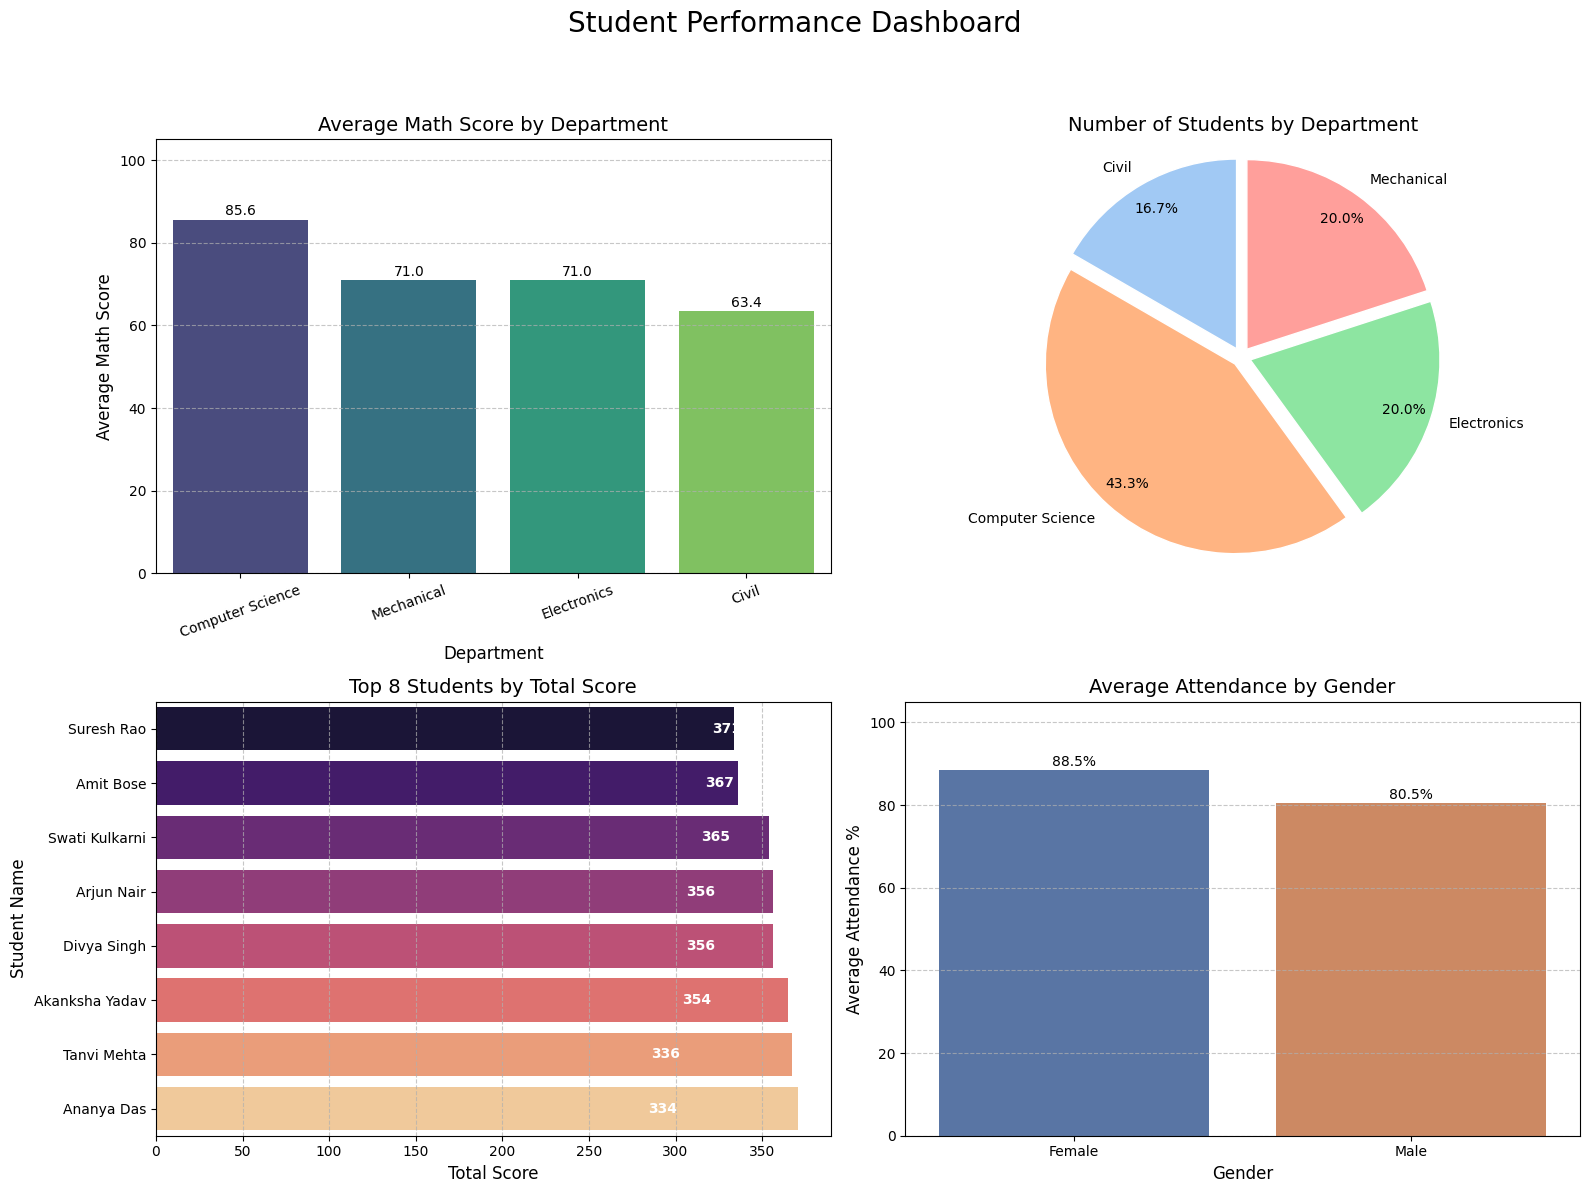

In [47]:
# Set up the figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Student Performance Dashboard', fontsize=20, y=1.02)

# --- Panel 1: Vertical Bar Chart (Average Math Score by Department) ---
sns.barplot(x='department', y='average_math_score', data=avg_math_by_dept, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Average Math Score by Department', fontsize=14)
axes[0, 0].set_xlabel('Department', fontsize=12)
axes[0, 0].set_ylabel('Average Math Score', fontsize=12)
axes[0, 0].set_ylim(0, 105)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0, 0].tick_params(axis='x', rotation=20) # Rotate labels if they overlap
for index, row in avg_math_by_dept.iterrows():
    axes[0, 0].text(index, row['average_math_score'] + 1, f'{row['average_math_score']:.1f}', color='black', ha="center")

# --- Panel 2: Pie Chart (Number of Students in Each Department) ---
colors = sns.color_palette('pastel')[0:len(students_by_dept)]
explode = [0.05] * len(students_by_dept)
axes[0, 1].pie(students_by_dept['number_of_students'], labels=students_by_dept['department'], autopct='%1.1f%%', colors=colors, explode=explode, pctdistance=0.85, startangle=90, wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
axes[0, 1].set_title('Number of Students by Department', fontsize=14)
axes[0, 1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# --- Panel 3: Horizontal Bar Chart (Top 8 Students based on Total Marks) ---
# Sort for visualization: highest scorer at the top
top_8_students_sorted = top_8_students.sort_values(by='total_score', ascending=True)
sns.barplot(x='total_score', y='name', data=top_8_students_sorted, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Top 8 Students by Total Score', fontsize=14)
axes[1, 0].set_xlabel('Total Score', fontsize=12)
axes[1, 0].set_ylabel('Student Name', fontsize=12)
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.7)
for index, row in top_8_students_sorted.iterrows():
    axes[1, 0].text(row['total_score'] - 50, index, f'{row['total_score']}', color='white', va='center', ha='left', fontweight='bold')

# --- Panel 4: Bar Chart (Average Attendance Percentage by Gender) ---
sns.barplot(x='gender', y='average_attendance_percentage', data=avg_attendance_by_gender, ax=axes[1, 1], palette='deep')
axes[1, 1].set_title('Average Attendance by Gender', fontsize=14)
axes[1, 1].set_xlabel('Gender', fontsize=12)
axes[1, 1].set_ylabel('Average Attendance %', fontsize=12)
axes[1, 1].set_ylim(0, 105)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)
for index, row in avg_attendance_by_gender.iterrows():
    axes[1, 1].text(index, row['average_attendance_percentage'] + 1, f'{row['average_attendance_percentage']:.1f}%', color='black', ha="center")

# Adjust layout and save the dashboard
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust rect to make space for the super title
plt.savefig('student_dashboard.png', dpi=150, bbox_inches='tight')

print("Dashboard saved successfully as 'student_dashboard.png'")

# Close the connection to the SQLite database
conn.close()
print("SQLite database connection closed.")